In [21]:
def accuracy(y_true, y_pred):
    correct_counter = 0
    for yt, yp in zip(y_true, y_pred):
        if yt == yp:
            correct_counter += 1
    return correct_counter / len(y_true)

In [22]:
l1 = [0, 1, 1, 1, 0, 0, 0, 1]
l2 = [0, 1, 0, 1, 0, 1, 0, 0]

accuracy(l1, l2)

0.625

In [23]:
from sklearn import metrics

metrics.accuracy_score(l1, l2)

0.625

In [24]:
def true_positive(y_true, y_pred):
    tp = 0
    for yt, yp in zip(y_true, y_pred):
        if yt == 1 and yp == 1:
            tp += 1
    return tp

def true_negative(y_true, y_pred):
    tn = 0
    for yt, yp in zip(y_true, y_pred):
        if yt == 0 and yp == 0:
            tn += 1
    return tn

def false_positive(y_true, y_pred):
    fp = 0
    for yt, yp in zip(y_true, y_pred):
        if yt == 0 and yp == 1:
            fp += 1
    return fp

def false_negative(y_true, y_pred):
    fn = 0
    for yt, yp in zip(y_true, y_pred):
        if yt == 1 and yp == 0:
            fn += 1
    return fn

In [25]:
print(f'True positive: {true_positive(l1, l2)}')
print(f'True negative: {true_negative(l1, l2)}')
print(f'False positive: {false_positive(l1, l2)}')
print(f'False negative: {false_negative(l1, l2)}')

True positive: 2
True negative: 3
False positive: 1
False negative: 2


$$
accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$

In [26]:
def accuracy_v2(y_true, y_pred): 
    tp = true_positive(y_true, y_pred) 
    fp = false_positive(y_true, y_pred) 
    fn = false_negative(y_true, y_pred) 
    tn = true_negative(y_true, y_pred) 
    accuracy_score = (tp + tn) / (tp + tn + fp + fn) 
    return accuracy_score 

accuracy_v2(l1, l2)

0.625

$Precision = \frac{TP}{TP + FP}$

In [27]:
def precision(y_true, y_pred): 
    tp = true_positive(y_true, y_pred) 
    fp = false_positive(y_true, y_pred) 
    precision = tp / (tp + fp) 
    return precision 

precision(l1, l2)

0.6666666666666666

The recall reflects the model's ability to identify actual positive samples.

$$
Recall = \frac{TP}{TP + FN}
$$

In [28]:
def recall(y_true, y_pred): 
    tp = true_positive(y_true, y_pred) 
    fn = false_negative(y_true, y_pred) 
    recall = tp / (tp + fn) 
    return recall

recall(l1, l2)

0.5

**Precision-Recall Curve**: For every threshold we choose, we calculate the precision and recall values, we can create a plot between these sets of values.

Text(0, 0.5, 'Precision')

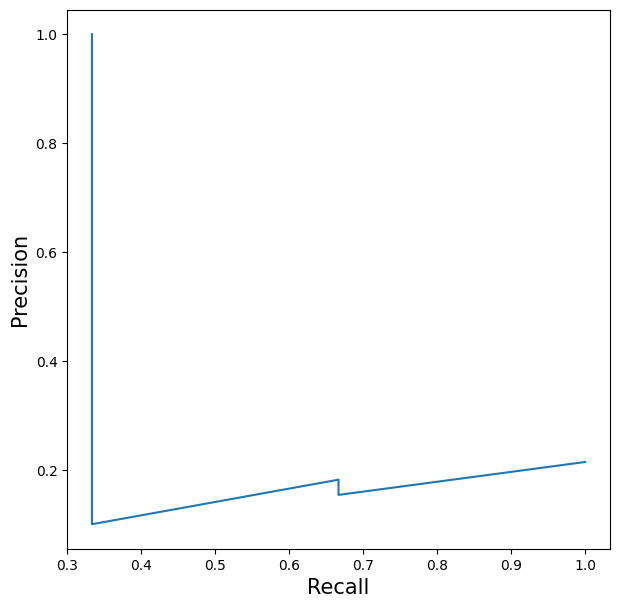

In [29]:
import matplotlib.pyplot as plt

y_true = [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 
          1, 0, 0, 0, 0, 0, 0, 0, 1, 0]
y_pred = [0.02638412, 0.11114267, 0.31620708,           
          0.0490937,  0.0191491,  0.17554844,        
          0.15952202, 0.03819563, 0.11639273, 
          0.079377,   0.08584789, 0.39095342, 
          0.27259048, 0.03447096, 0.04644807, 
          0.03543574, 0.18521942, 0.05934905, 
          0.61977213, 0.33056815] 

precisions = []
recalls = []
thresholds = [0.0490937 , 0.05934905, 0.079377,  
              0.08584789, 0.11114267, 0.11639273,  
              0.15952202, 0.17554844, 0.18521942,  
              0.27259048, 0.31620708, 0.33056815,  
              0.39095342, 0.61977213] 

for threshold in thresholds:
    prediction = [1 if x >= threshold else 0 for x in y_pred]
    p = precision(y_true, prediction)
    r = recall(y_true, prediction)
    precisions.append(p)
    recalls.append(r)

plt.figure(figsize=(7, 7))
plt.plot(recalls, precisions)
plt.xlabel('Recall', fontsize=15)
plt.ylabel('Precision', fontsize=15)

F1 score is a metric that combines both precision and recall. It is defined as a simple weighted average (harmonic mean) of precision and recall. If we denote precision using P and recall using R, we can represent the F1 score as:

$$
F1 = \frac{2PR}{P + R} = \frac{2TP}{2TP + FP + FN}
$$

In [30]:
def f1(y_true, y_pred): 
    p = precision(y_true, y_pred) 
    r = recall(y_true, y_pred) 
    score = 2 * p * r / (p + r) 
    return score

y_true = [0, 0, 0, 1, 0, 0, 0, 0, 0, 0,      
          1, 0, 0, 0, 0, 0, 0, 0, 1, 0] 
y_pred = [0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 
          1, 0, 0, 0, 0, 0, 0, 0, 1, 0]

f1(y_true, y_pred)

0.5714285714285715

In [31]:
from sklearn.metrics import f1_score
f1_score(y_true, y_pred)

0.5714285714285714

When dealing with datasets that have **skewed targets**, we should look at F1 (or precision and recall) instead of accuracy. 

True Positive Rate(TPR): 

$$
TPR = \frac{TP}{TP + FN}
$$

TPR or recall is also known as **sensitivity**. 

In [32]:
def tpr(y_true, y_pred):
    return recall(y_true, y_pred)

**False Positive Rate**(FPR):

$$
FRP = \frac{FP}{TN + FP}
$$

And $1 - FPR$ is known as **specificity** or **True Negative Rate**(TNR).

In [33]:
def fpr(y_true, y_pred):
    fp = false_positive(y_true, y_pred)
    tn = true_negative(y_true, y_pred)
    return fp / (tn + fp)

In [34]:
tpr_list = []
fpr_list = []

y_true = [0, 0, 0, 0, 1,
          0, 1, 0, 0, 1,
          0, 1, 0, 0, 1]
y_pred = [0.1, 0.3, 0.2, 0.6, 0.8, 
          0.05, 0.9, 0.5, 0.3, 0.66,
          0.3, 0.2, 0.85, 0.15, 0.99]
thresholds = [0, 0.1, 0.2, 0.3, 
              0.4, 0.5, 0.6, 0.7, 
              0.8, 0.85, 0.9, 0.99, 
              1.0]

for thresh in thresholds:
    temp_pred = [1 if x >= thresh else 0 for x in y_pred]
    temp_tpr = tpr(y_true, temp_pred)
    temp_fpr = fpr(y_true, temp_pred)
    tpr_list.append(temp_tpr)
    fpr_list.append(temp_fpr)

In [36]:
import pandas as pd

df = pd.DataFrame({
    'threshold': thresholds,
    'tpr': tpr_list,
    'fpr': fpr_list
})

df

,threshold,tpr,fpr
0,0.00,1.0,1.0
1,0.10,1.0,0.9
2,0.20,1.0,0.7
3,0.30,0.8,0.6
4,0.40,0.8,0.3
5,0.50,0.8,0.3
6,0.60,0.8,0.2
7,0.70,0.6,0.1
8,0.80,0.6,0.1
9,0.85,0.4,0.1


**Receiver Operating Characteristic**(ROC) curve will tell you how the threshold impacts false positive rate and true positive rate and thus, in turn, false positives and true positives. You should choose the threshold that is best suited for your problem and datasets.

2 ways to determine the best threshold in ROC curves: 

1. **Youden's J statistic**: $ J = Sensitivity + Specificity - 1 = TPR + (1 - FPR) - 1 $. The best threshold is at the point that maximizes the value of J.

2. **Distance to point (0, 1)**: The best threshold is at the point nearest to (0, 1).

And the area under ROC curve is called **AUC**. AUC values range from 0 to 1.

- AUC = 1 / 0 implies you may have a perfect model. If AUC = 0, try inverting the probabilities for the predictions.

- AUC = 0.5 implies that your predictions are random.

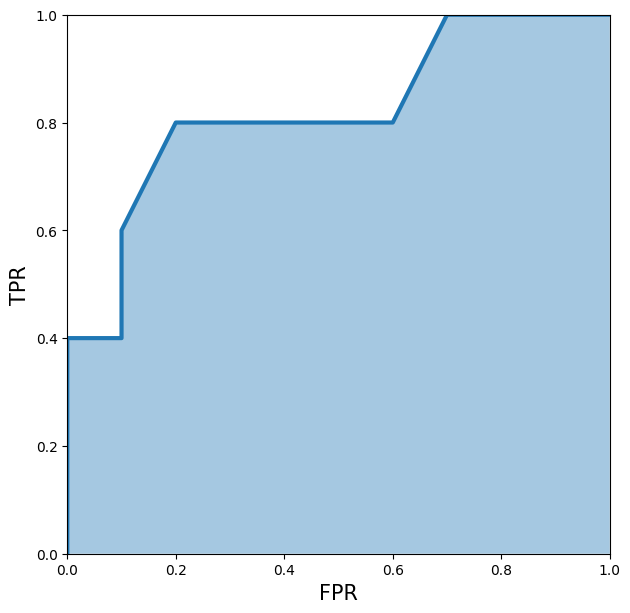

In [37]:
plt.figure(figsize=(7, 7)) 
plt.fill_between(fpr_list, tpr_list, alpha=0.4) 
plt.plot(fpr_list, tpr_list, lw=3) 
plt.xlim(0, 1.0) 
plt.ylim(0, 1.0) 
plt.xlabel('FPR', fontsize=15) 
plt.ylabel('TPR', fontsize=15) 
plt.show() 

**Log Loss**: 

$$
\text{Log Loss} = -[\text{target} \cdot \log(\text{prediction}) + (1 - \text{target}) \cdot \log(1 - \text{prediction})]
$$

Where target is either 0 or 1 and prediction is a probability of a sample belonging to class 1

In [38]:
import numpy as np

def log_loss(y_true, y_proba):
    eps = 1e-12
    loss = []
    for yt, yp in zip(y_true, y_proba):
        # Clip the predicted probabilities to the range [eps, 1-eps] to avoid infinite or invalid values during logarithmic calculations 
        yp = np.clip(yp, eps, 1 - eps) 
        temp_loss = -1.0 * (yt * np.log(yp) + (1 - yt) * np.log(1 - yp))
        loss.append(temp_loss)
    return np.mean(loss)

log_loss(y_true, y_pred)

0.49882711861432294

In [39]:
from sklearn.metrics import log_loss
log_loss(y_true, y_pred)

0.49882711861432294